# 05 — Model Explainability

Interprets the production model (`src/final_pipeline.py`) — the same HistGradientBoosting
pipeline trained by `python -m src.train` and used by the Streamlit app.

Explainability here means "what is this model of historical data associating with subscribing,"
not causal inference: it does not show that changing a feature would change a real customer's
behavior, only that the two were correlated in the training data.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.data_loader import load_bank_data
from src.final_pipeline import build_final_pipeline
from src.explainability import top_feature_importance
from src.preprocessing import split_features_target
from src.config import RANDOM_STATE, TEST_SIZE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

raw_df = load_bank_data()
model, metrics = build_final_pipeline(raw_df)
print(f"Decision threshold: {metrics['decision_threshold']:.3f}")
for name, value in metrics['test_metrics'].items():
    print(f'  {name:20} {value:.4f}')

Decision threshold: 0.250
  accuracy             0.8832
  precision            0.4845
  recall               0.5722
  f1                   0.5247
  roc_auc              0.8133
  average_precision    0.4920


## Feature importance

`HistGradientBoostingClassifier` exposes neither `coef_` nor `feature_importances_`, so importance is measured by permutation on a held-out split instead: shuffle one original column at a time (not one one-hot dummy at a time) and measure how much held-out ROC-AUC drops. `top_feature_importance` picks this path automatically whenever the model has no native importances, and aggregates one-hot categories back into a single score per original column either way.

In [2]:
# The same split `build_final_pipeline` used internally for its own test evaluation,
# recreated here to get held-out rows to permute rather than reusing training rows.
X, y = split_features_target(raw_df)
_, X_test, _, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

importance = top_feature_importance(model, X_test, y_test, top_n=15)
importance

,feature,importance,abs_importance
0,nr.employed,0.059828,0.059828
1,euribor3m,0.027898,0.027898
2,contact,0.019594,0.019594
3,cons.price.idx,0.012275,0.012275
4,cons.conf.idx,0.010257,0.010257
5,emp.var.rate,0.006210,0.006210
6,pdays,0.004966,0.004966
7,month,0.004169,0.004169
8,campaign,0.003437,0.003437
9,day_of_week,0.002962,0.002962


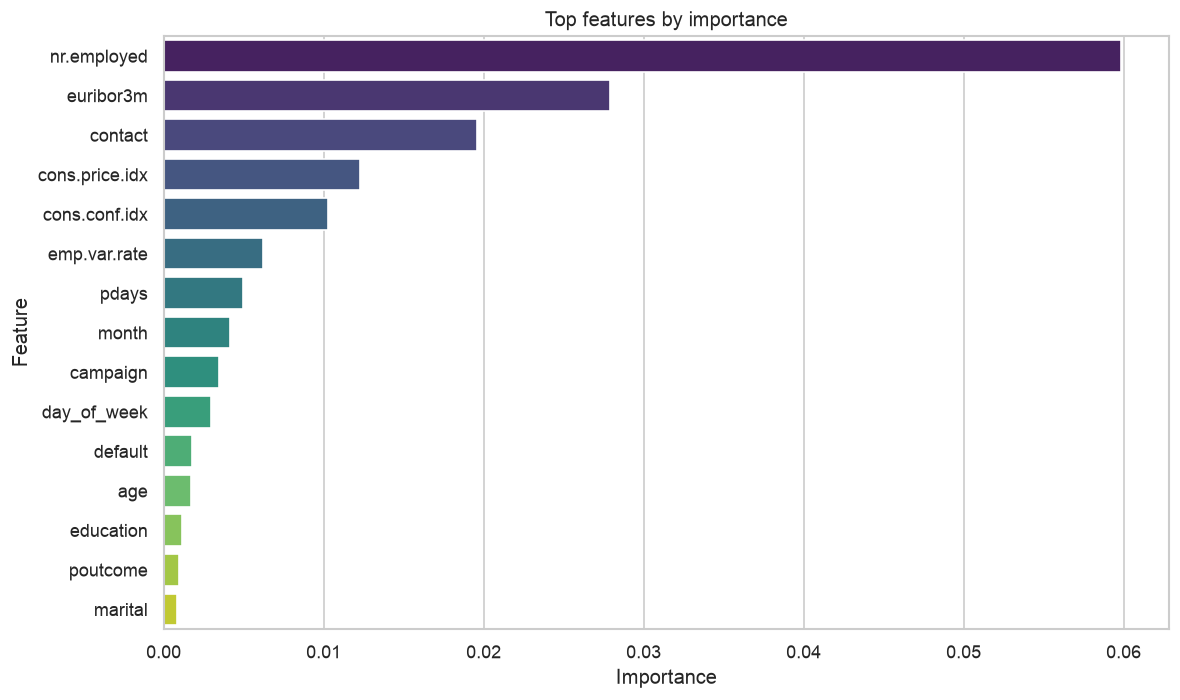

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance, x='abs_importance', y='feature', hue='feature', palette='viridis', legend=False, ax=ax)
ax.set_title('Top features by importance')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

By permutation importance, `nr.employed`, `euribor3m`, `contact` type, and the other economic indicators dominate — consistent with notebook 02's finding that they explain most of the month-to-month swing in conversion rate. `pdays` (contact recency) sits mid-table and `poutcome` (prior outcome) ranks lowest, which looks like a contradiction of notebook 02's finding that prior-contact history has the largest raw effect on conversion (6x lift).

It isn't one: raw response rate and permutation importance answer different questions. Response rate asks 'how much does the outcome differ between groups'; permutation importance asks 'how much unique predictive information does this column add once every other column is already in the model.' `poutcome`, `pdays` and `previous` are highly redundant with each other (and inherit timing information that correlates with the economic columns), so once the model has any one of them plus the economic indicators, shuffling the other prior-contact columns individually costs it less than their raw marginal effect would suggest. The lesson for the business reader: prior-contact history is still a real and strong signal — just don't read single-feature importance rankings as saying that signal doesn't matter.

## Responsible use

- Treat the output as a prioritization score, not a certainty — see the app's own framing in `app/app.py`.
- Don't use this model (or any model trained on this kind of historical contact data) to *exclude* customers from being offered products; use it to sequence limited outreach capacity.
- Re-validate periodically: notebook 04 found performance is reasonably stable across a temporal split, but the economic indicators the model leans on will drift, and `poutcome` requires the bank to have already run a prior campaign — a genuinely new customer is scored using only 'nonexistent' for that field, which resembles the largest and lowest-converting segment in the training data.